<a href="https://colab.research.google.com/github/SURUSAIKEERTHI/DSA0203/blob/main/CO2_AT2_192424368_SURU_SAI_KEERTHI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving barcode.jpeg to barcode.jpeg
===== THRESHOLDING ANALYSIS =====

Image Size: (731, 1280)

Global Threshold = 127
Otsu Threshold = 143.0

Original Grayscale:
Minimum Intensity = 1
Maximum Intensity = 255
Mean Intensity = 188.07
Standard Deviation = 54.69

===== GLOBAL THRESHOLDING =====
Black Pixels = 105010
White Pixels = 830670
Black Pixel Percentage = 11.22 %

===== ADAPTIVE THRESHOLDING =====
Black Pixels = 82990
White Pixels = 852690
Black Pixel Percentage = 8.87 %


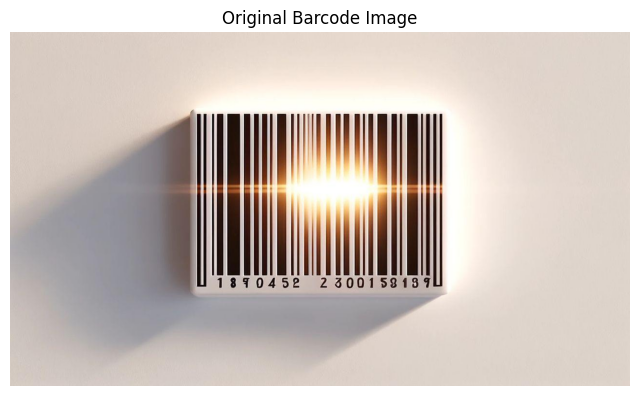

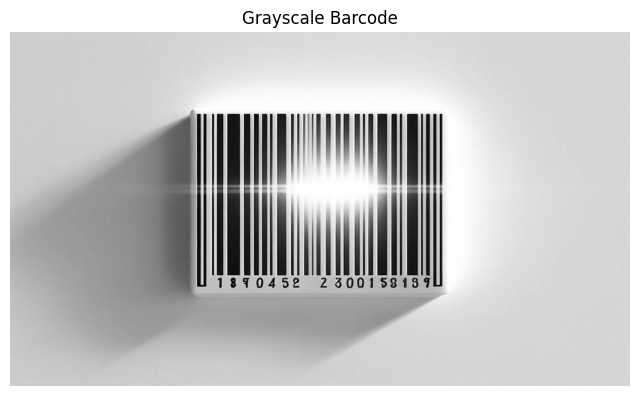

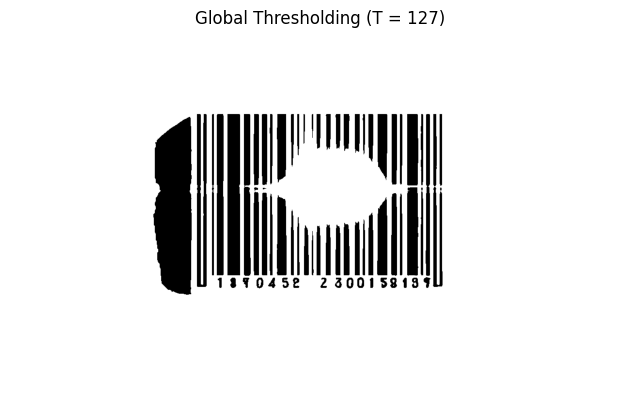

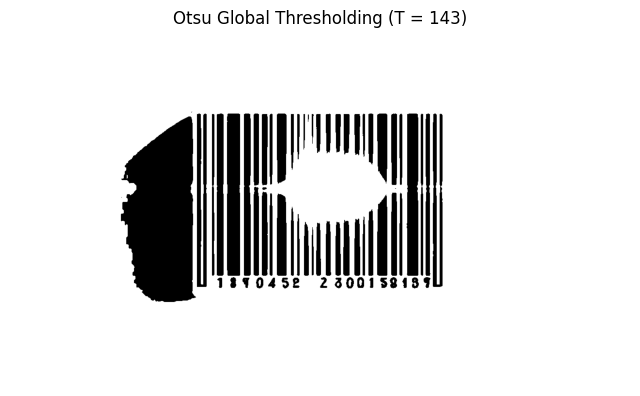

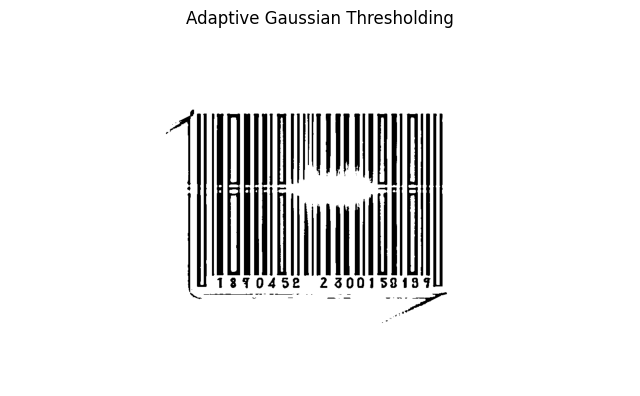

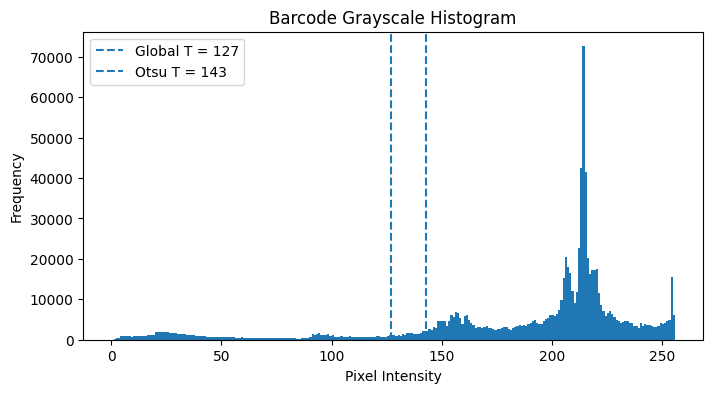

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------
# 1. UPLOAD BARCODE IMAGE
# ------------------------------------------

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

if img is None:
    print("Error: Image could not be loaded!")

else:
    # Convert BGR to RGB for displaying
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ------------------------------------------
    # 2. CONVERT TO GRAYSCALE
    # ------------------------------------------

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ------------------------------------------
    # 3. NOISE REDUCTION
    # ------------------------------------------

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # ------------------------------------------
    # 4. GLOBAL THRESHOLDING
    # ------------------------------------------

    T = 127

    _, global_thresh = cv2.threshold(
        blurred,
        T,
        255,
        cv2.THRESH_BINARY
    )

    # ------------------------------------------
    # 5. ADAPTIVE THRESHOLDING
    # ------------------------------------------

    adaptive_thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,    # Neighborhood size
        5      # Constant C
    )

    # ------------------------------------------
    # 6. OTSU THRESHOLDING
    # ------------------------------------------

    otsu_T, otsu_thresh = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # ------------------------------------------
    # 7. NUMERICAL ANALYSIS
    # ------------------------------------------

    print("===== THRESHOLDING ANALYSIS =====")

    print("\nImage Size:", gray.shape)

    print("\nGlobal Threshold =", T)
    print("Otsu Threshold =", round(otsu_T, 2))

    print("\nOriginal Grayscale:")
    print("Minimum Intensity =", np.min(gray))
    print("Maximum Intensity =", np.max(gray))
    print("Mean Intensity =", round(np.mean(gray), 2))
    print("Standard Deviation =", round(np.std(gray), 2))

    # Count black and white pixels
    global_black = np.sum(global_thresh == 0)
    global_white = np.sum(global_thresh == 255)

    adaptive_black = np.sum(adaptive_thresh == 0)
    adaptive_white = np.sum(adaptive_thresh == 255)

    total = gray.size

    print("\n===== GLOBAL THRESHOLDING =====")
    print("Black Pixels =", global_black)
    print("White Pixels =", global_white)
    print(
        "Black Pixel Percentage =",
        round((global_black / total) * 100, 2),
        "%"
    )

    print("\n===== ADAPTIVE THRESHOLDING =====")
    print("Black Pixels =", adaptive_black)
    print("White Pixels =", adaptive_white)
    print(
        "Black Pixel Percentage =",
        round((adaptive_black / total) * 100, 2),
        "%"
    )

    # ------------------------------------------
    # 8. DISPLAY ORIGINAL IMAGE
    # ------------------------------------------

    plt.figure(figsize=(8, 5))
    plt.imshow(rgb)
    plt.title("Original Barcode Image")
    plt.axis("off")
    plt.show()

    # ------------------------------------------
    # 9. GRAYSCALE
    # ------------------------------------------

    plt.figure(figsize=(8, 5))
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Barcode")
    plt.axis("off")
    plt.show()

    # ------------------------------------------
    # 10. GLOBAL THRESHOLD
    # ------------------------------------------

    plt.figure(figsize=(8, 5))
    plt.imshow(global_thresh, cmap="gray")
    plt.title("Global Thresholding (T = 127)")
    plt.axis("off")
    plt.show()

    # ------------------------------------------
    # 11. OTSU THRESHOLD
    # ------------------------------------------

    plt.figure(figsize=(8, 5))
    plt.imshow(otsu_thresh, cmap="gray")
    plt.title(f"Otsu Global Thresholding (T = {int(otsu_T)})")
    plt.axis("off")
    plt.show()

    # ------------------------------------------
    # 12. ADAPTIVE THRESHOLD
    # ------------------------------------------

    plt.figure(figsize=(8, 5))
    plt.imshow(adaptive_thresh, cmap="gray")
    plt.title("Adaptive Gaussian Thresholding")
    plt.axis("off")
    plt.show()

    # ------------------------------------------
    # 13. HISTOGRAM
    # ------------------------------------------

    plt.figure(figsize=(8, 4))

    plt.hist(
        gray.ravel(),
        bins=256,
        range=[0, 256]
    )

    plt.axvline(
        T,
        linestyle="--",
        label="Global T = 127"
    )

    plt.axvline(
        otsu_T,
        linestyle="--",
        label=f"Otsu T = {int(otsu_T)}"
    )

    plt.title("Barcode Grayscale Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()